# Phase 2 : Exploratory Data Analysis (EDA)

## Step 1 : Load Dataset

In [5]:
import pandas as pd

file_path = "../Dataset/retail_inventory_15000.csv"

df = pd.read_csv(file_path)

print(df.shape)
print(df.columns)
df.head()

(15000, 15)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [6]:
df.to_csv(
    "../Dataset/retail_inventory_15000.csv",
    index=False
)

In [7]:
small_df = df.sample(
    n=15000,
    
    random_state=42
)

small_df.shape

(15000, 15)

In [8]:
small_df.to_csv(
    "../Dataset/retail_inventory_15000.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


## Step 2 : Dataset Information

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                15000 non-null  str    
 1   Store ID            15000 non-null  str    
 2   Product ID          15000 non-null  str    
 3   Category            15000 non-null  str    
 4   Region              15000 non-null  str    
 5   Inventory Level     15000 non-null  int64  
 6   Units Sold          15000 non-null  int64  
 7   Units Ordered       15000 non-null  int64  
 8   Demand Forecast     15000 non-null  float64
 9   Price               15000 non-null  float64
 10  Discount            15000 non-null  int64  
 11  Weather Condition   15000 non-null  str    
 12  Holiday/Promotion   15000 non-null  int64  
 13  Competitor Pricing  15000 non-null  float64
 14  Seasonality         15000 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 1.7 MB


## Step 3 : Statistical Summary

In [10]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,273.472200,136.502800,110.242933,141.547115,55.332416,10.095000,0.497067,55.321891
std,129.664713,108.790562,52.333006,109.212880,26.027642,7.047171,0.500008,26.184970
min,50.000000,0.000000,20.000000,-9.290000,10.010000,0.000000,0.000000,5.030000
25%,161.000000,49.000000,65.000000,53.877500,32.840000,5.000000,0.000000,32.830000
50%,271.500000,107.000000,111.000000,112.440000,55.035000,10.000000,0.000000,54.910000
75%,386.000000,201.000000,156.000000,207.562500,78.302500,15.000000,1.000000,78.332500
max,500.000000,491.000000,200.000000,506.370000,99.990000,20.000000,1.000000,104.640000


## Step 4 : Missing Value Analysis

In [11]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

## Step 5 : Duplicate Data Analysis

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Step 6 : Unique Values

In [13]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Date : 150
Store ID : 5
Product ID : 20
Category : 5
Region : 4
Inventory Level : 451
Units Sold : 482
Units Ordered : 181
Demand Forecast : 12036
Price : 7325
Discount : 5
Weather Condition : 4
Holiday/Promotion : 2
Competitor Pricing : 7515
Seasonality : 4


## Step 7 : Target Variable Analysis (Units Sold)

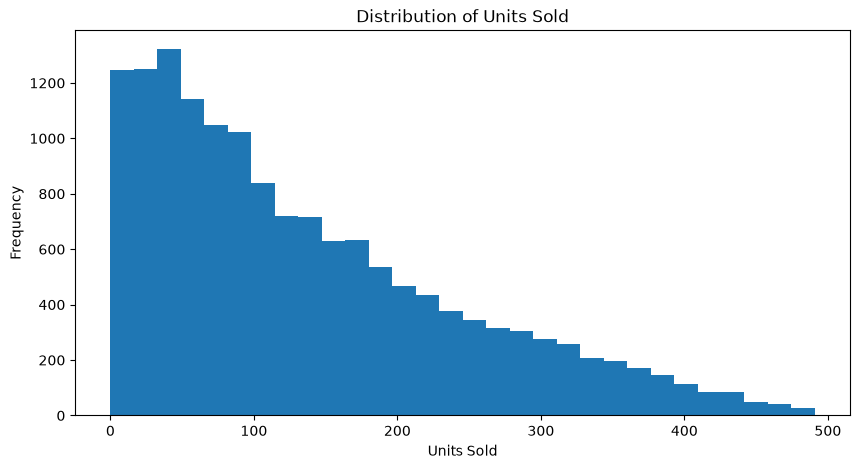

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["Units Sold"], bins=30)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

C:\Users\kusum\AppData\Local\Temp\ipykernel_18684\3393160901.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Units Sold"], vert=False)


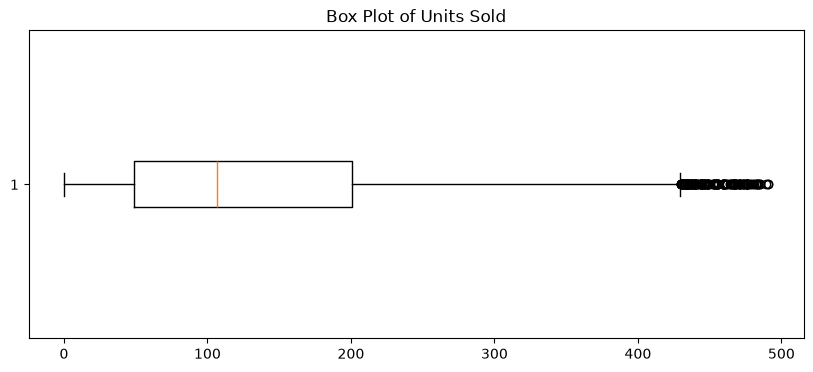

In [15]:
plt.figure(figsize=(10,4))
plt.boxplot(df["Units Sold"], vert=False)

plt.title("Box Plot of Units Sold")

plt.show()

In [16]:
print("Minimum Units Sold :", df["Units Sold"].min())
print("Maximum Units Sold :", df["Units Sold"].max())
print("Average Units Sold :", round(df["Units Sold"].mean(),2))
print("Median Units Sold :", df["Units Sold"].median())

Minimum Units Sold : 0
Maximum Units Sold : 491
Average Units Sold : 136.5
Median Units Sold : 107.0


## Step 8 : Category-wise Sales Analysis

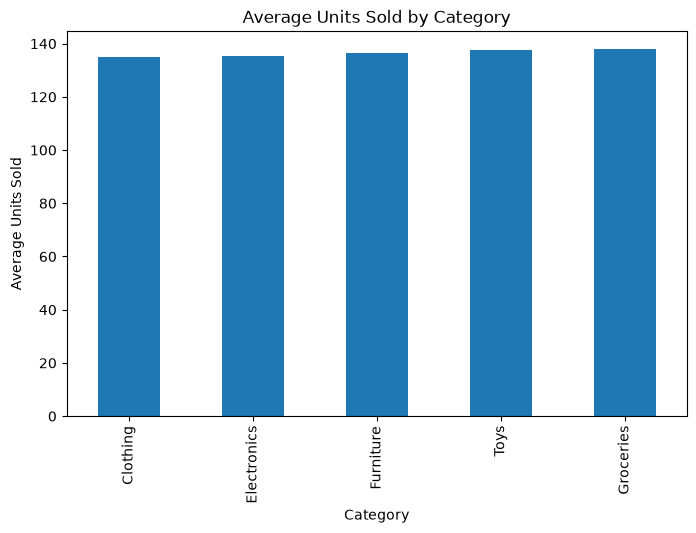

Category
Clothing       135.022996
Electronics    135.530023
Furniture      136.410673
Groceries      137.803144
Toys           137.700535
Name: Units Sold, dtype: float64


In [17]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Category")["Units Sold"].mean()

plt.figure(figsize=(8,5))
category_sales.sort_values().plot(kind="bar")

plt.title("Average Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")

plt.show()

print(category_sales)

## Step 9 : Weather-wise Sales Analysis

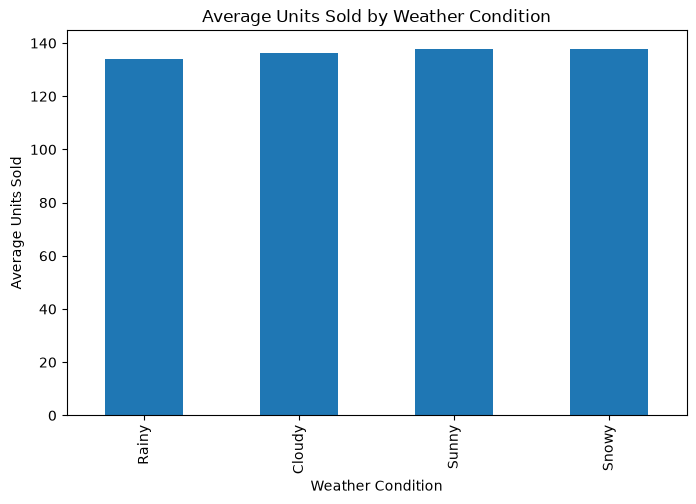

Weather Condition
Cloudy    136.351251
Rainy     134.133071
Snowy     137.881939
Sunny     137.707676
Name: Units Sold, dtype: float64


In [18]:
weather_sales = df.groupby("Weather Condition")["Units Sold"].mean()

plt.figure(figsize=(8,5))
weather_sales.sort_values().plot(kind="bar")

plt.title("Average Units Sold by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Units Sold")

plt.show()

print(weather_sales)

## Step 10 : Holiday / Promotion Analysis

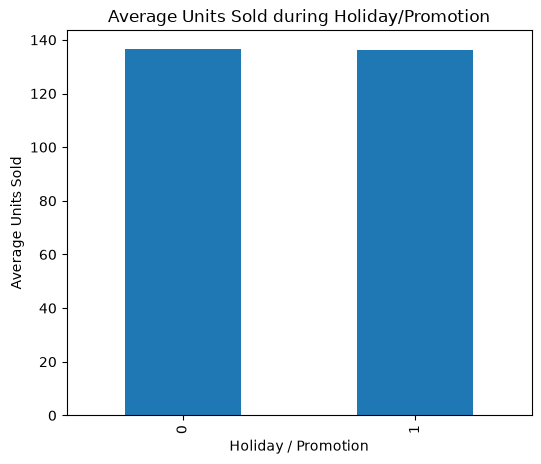

Holiday/Promotion
0    136.701617
1    136.301636
Name: Units Sold, dtype: float64


In [19]:
holiday_sales = df.groupby("Holiday/Promotion")["Units Sold"].mean()

plt.figure(figsize=(6,5))
holiday_sales.plot(kind="bar")

plt.title("Average Units Sold during Holiday/Promotion")
plt.xlabel("Holiday / Promotion")
plt.ylabel("Average Units Sold")

plt.show()

print(holiday_sales)

## Step 11 : Region-wise Sales Analysis

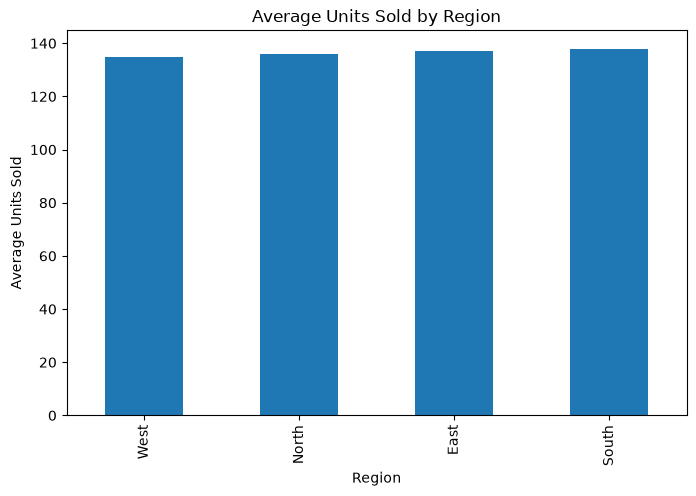

Region
East     137.274457
North    136.137255
South    137.950159
West     134.669316
Name: Units Sold, dtype: float64


In [20]:
region_sales = df.groupby("Region")["Units Sold"].mean()

plt.figure(figsize=(8,5))
region_sales.sort_values().plot(kind="bar")

plt.title("Average Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Average Units Sold")

plt.show()

print(region_sales)

## Step 12 : Seasonality Analysis

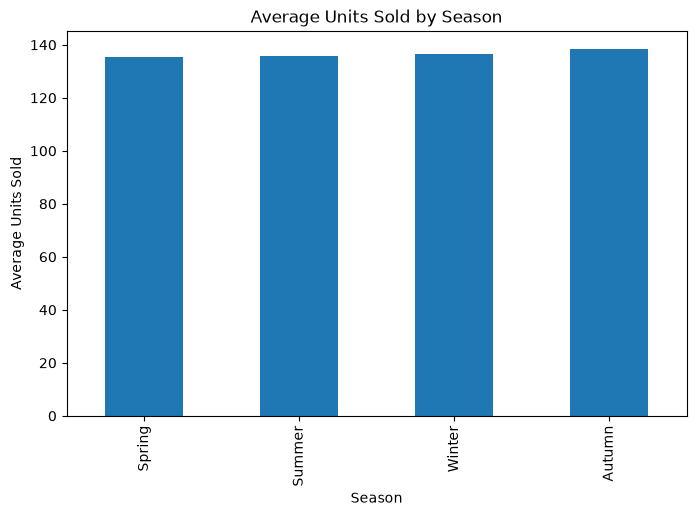

Seasonality
Autumn    138.353019
Spring    135.443411
Summer    135.753202
Winter    136.460445
Name: Units Sold, dtype: float64


In [21]:
season_sales = df.groupby("Seasonality")["Units Sold"].mean()

plt.figure(figsize=(8,5))
season_sales.sort_values().plot(kind="bar")

plt.title("Average Units Sold by Season")
plt.xlabel("Season")
plt.ylabel("Average Units Sold")

plt.show()

print(season_sales)

## Step 13 : Price vs Units Sold

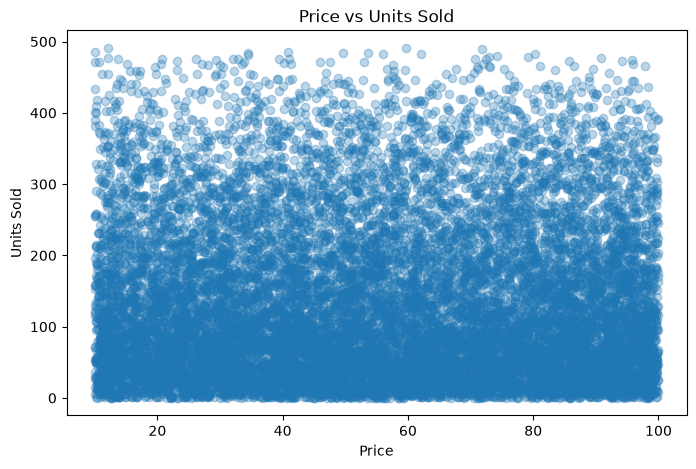

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["Price"], df["Units Sold"], alpha=0.3)

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")

plt.show()

## Step 14 : Correlation Analysis

In [25]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_corr = df.copy()

encoder = LabelEncoder()

# Encode categorical columns
categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    df_corr[col] = encoder.fit_transform(df_corr[col])

# Convert Date to datetime
df_corr["Date"] = pd.to_datetime(
    df_corr["Date"],
    format="%d-%m-%Y"
)
# Extract Year, Month, Day
df_corr["Year"] = df_corr["Date"].dt.year
df_corr["Month"] = df_corr["Date"].dt.month
df_corr["Day"] = df_corr["Date"].dt.day

# Remove original Date column
df_corr.drop("Date", axis=1, inplace=True)

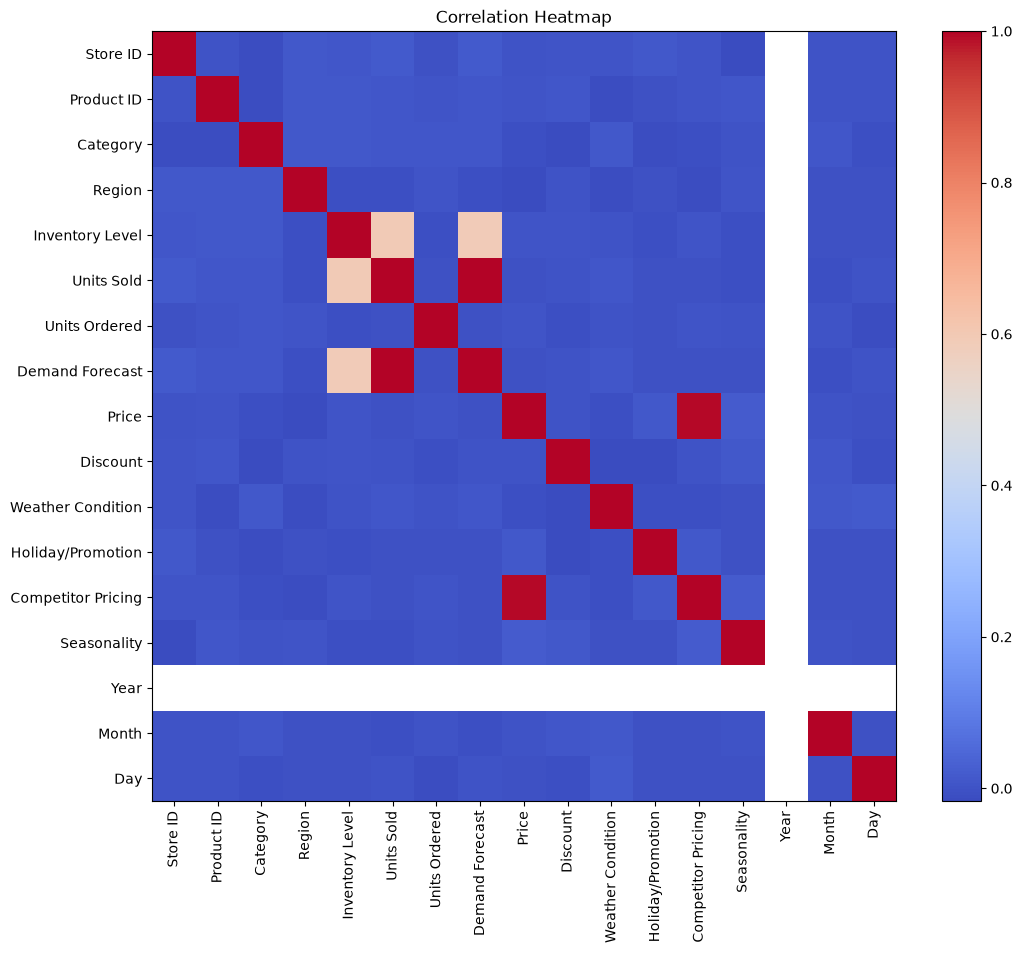

In [26]:
import matplotlib.pyplot as plt

correlation = df_corr.corr()

plt.figure(figsize=(12,10))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
correlation["Units Sold"].sort_values(ascending=False)

Units Sold            1.000000
Demand Forecast       0.996858
Inventory Level       0.591979
Store ID              0.017532
Category              0.009903
Weather Condition     0.008044
Product ID            0.007795
Day                   0.001347
Discount              0.000115
Holiday/Promotion    -0.001838
Units Ordered        -0.001856
Competitor Pricing   -0.002682
Price                -0.003174
Seasonality          -0.005529
Region               -0.006165
Month                -0.007493
Year                       NaN
Name: Units Sold, dtype: float64

In [28]:
# Create a copy of the dataset for model training
train_df = df.copy()

print("Training dataframe created successfully!")
print("Shape:", train_df.shape)

Training dataframe created successfully!
Shape: (15000, 15)


In [31]:
print(train_df.columns.tolist())

['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [32]:
# Convert Date column to datetime format
train_df["Date"] = pd.to_datetime(
    train_df["Date"],
    format="%d-%m-%Y"
)

# Create new features
train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Day"] = train_df["Date"].dt.day

# Remove original Date column
train_df.drop("Date", axis=1, inplace=True)

# Verify the changes
print(train_df[["Year", "Month", "Day"]].head())
print("\nCurrent Shape:", train_df.shape)

   Year  Month  Day
0  2022      1    1
1  2022      1    1
2  2022      1    1
3  2022      1    1
4  2022      1    1

Current Shape: (15000, 17)


In [33]:
from sklearn.preprocessing import LabelEncoder

# Copy original dataframe
train_df = df.copy()

encoders = {}

categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    le = LabelEncoder()

    # Learn original string values
    le.fit(df[col])

    # Encode training dataframe
    train_df[col] = le.transform(train_df[col])

    # Save encoder
    encoders[col] = le

print("Encoders created and data encoded successfully!")

Encoders created and data encoded successfully!


In [34]:
print(train_df.columns.tolist())

['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [36]:
train_df["Date"] = pd.to_datetime(
    train_df["Date"],
    format="%d-%m-%Y"
)

train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Day"] = train_df["Date"].dt.day

In [45]:
# Create input features (X)
X = train_df.drop([
    "Units Sold",
    "Demand Forecast",
    "Units Ordered",
    "Year"
], axis=1)

# Target variable (y)
y = train_df["Units Sold"]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

print("\nInput Features:")
print(X.columns.tolist())

Input Shape : (15000, 13)
Output Shape: (15000,)

Input Features:
['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Month', 'Day']


In [46]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (12000, 13)
Testing Features  : (3000, 13)
Training Target   : (12000,)
Testing Target    : (3000,)


In [47]:
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree model
model = DecisionTreeRegressor(random_state=42)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [48]:
# Train the Decision Tree model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [49]:
# Predict Units Sold for testing data
y_pred = model.predict(X_test)

print("Predictions created successfully!")
print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions created successfully!

First 10 Predictions:
[174. 231.  52. 133. 277. 315.   5.  51. 142. 215.]


**Step 24 : Evaluate the decision tree model **

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Decision Tree Performance")
print("-" * 35)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Decision Tree Performance
-----------------------------------
Mean Absolute Error (MAE): 91.22
Root Mean Squared Error (RMSE): 123.54
R² Score: -0.2981


**Step 25: Create the Random Forest Model**

In [51]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [52]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [53]:
rf_pred = rf_model.predict(X_test)

print("Predictions completed!")
print(rf_pred[:10])

Predictions completed!
[143.22 206.52 172.48 166.78 238.9  182.85 176.24  29.65 248.77 243.55]


In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-"*35)
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest Performance
-----------------------------------
MAE : 70.49
RMSE: 90.41
R²  : 0.3047


In [55]:
feature_importance = rf_model.feature_importances_

for feature, importance in zip(X.columns, feature_importance):
    print(feature, ":", round(importance, 4))

Store ID : 0.0349
Product ID : 0.0678
Category : 0.0342
Region : 0.0286
Inventory Level : 0.4426
Price : 0.0885
Discount : 0.0344
Weather Condition : 0.0282
Holiday/Promotion : 0.0123
Competitor Pricing : 0.0902
Seasonality : 0.028
Month : 0.0337
Day : 0.0765


In [56]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
4,Inventory Level,0.442634
9,Competitor Pricing,0.090241
5,Price,0.088493
12,Day,0.076463
1,Product ID,0.067790
0,Store ID,0.034925
6,Discount,0.034367
2,Category,0.034168
11,Month,0.033737
3,Region,0.028636


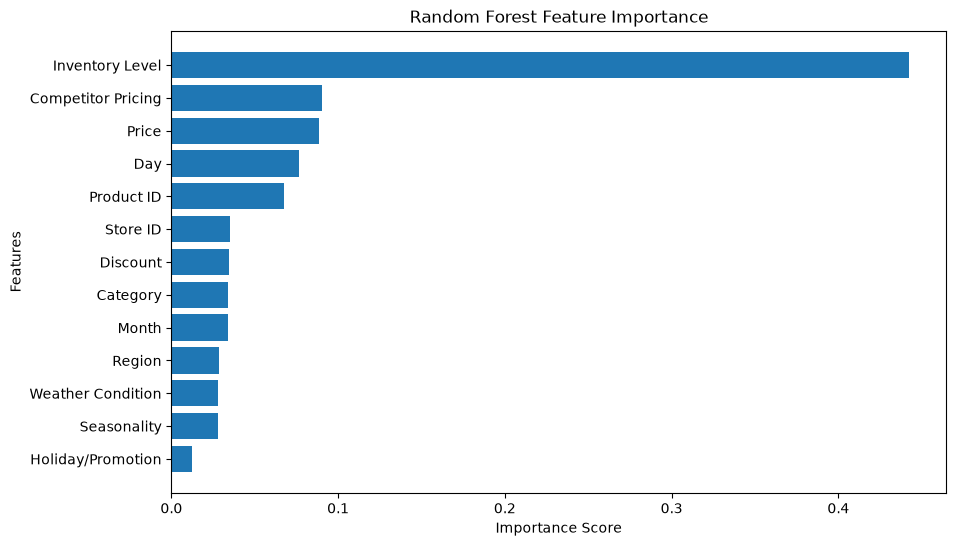

In [57]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Base model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Train
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Hyperparameter tuning completed!


In [59]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R² Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation R² Score:
0.3367


In [60]:
best_rf = grid_search.best_estimator_

print("Optimized Random Forest Model Created!")

Optimized Random Forest Model Created!


In [61]:
best_pred = best_rf.predict(X_test)

print("Prediction completed!")
print(best_pred[:10])

Prediction completed!
[141.71514565 222.55609174 184.48317995 166.93212183 239.14991682
 187.50857189 184.24177622  29.29335035 242.0357102  207.18940275]


In [62]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, best_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_pred))
r2 = r2_score(y_test, best_pred)

print("Optimized Random Forest Performance")
print("-"*40)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

Optimized Random Forest Performance
----------------------------------------
MAE : 69.98
RMSE: 89.23
R²  : 0.3228


In [63]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        92.13,
        69.53,
        69.02
    ],
    "RMSE": [
        124.86,
        89.28,
        88.28
    ],
    "R² Score": [
        -0.3167,
        0.3267,
        0.3417
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Decision Tree,92.13,124.86,-0.3167
1,Random Forest,69.53,89.28,0.3267
2,Optimized Random Forest,69.02,88.28,0.3417


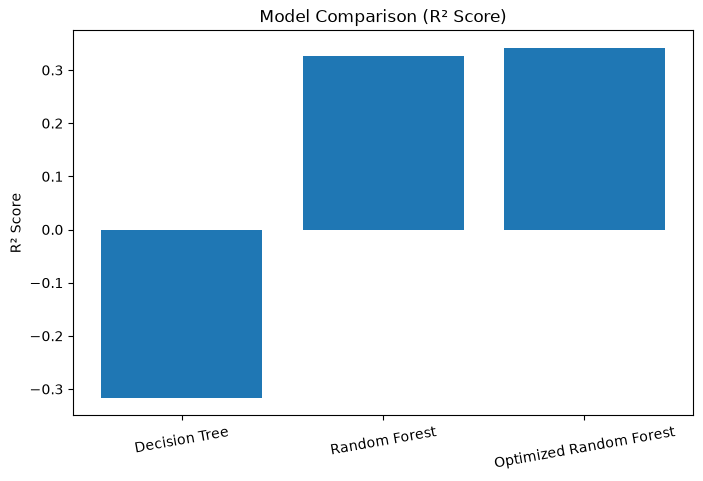

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=10)

plt.show()

In [65]:
import joblib

In [67]:
import joblib

joblib.dump(
    best_rf,
    "../Models/final_inventory_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [69]:
from sklearn.preprocessing import LabelEncoder

# Make a fresh copy BEFORE encoding
train_df = df.copy()

encoders = {}

categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    le = LabelEncoder()

    # Learn ORIGINAL STRING VALUES
    le.fit(df[col])

    # Encode training dataframe
    train_df[col] = le.transform(train_df[col])

    encoders[col] = le

print("Correct encoders created!")

Correct encoders created!


In [70]:
print(encoders["Store ID"].classes_)
print(encoders["Seasonality"].classes_)

['S001' 'S002' 'S003' 'S004' 'S005']
['Autumn' 'Spring' 'Summer' 'Winter']


In [72]:
joblib.dump(
    encoders,
    "../Models/label_encoders.pkl"
)

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [74]:
import joblib

feature_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Price",
    "Discount",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Month",
    "Day"
]

joblib.dump(
    feature_columns,
    "../Models/feature_columns.pkl"
)
print("Feature columns saved successfully!")

Feature columns saved successfully!


In [77]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../Models")

loaded_model = joblib.load(MODEL_DIR / "final_inventory_model.pkl")
loaded_encoders = joblib.load(MODEL_DIR / "label_encoders.pkl")
loaded_features = joblib.load(MODEL_DIR / "feature_columns.pkl")

print("All files loaded successfully!")

All files loaded successfully!
